Beta params: a=5.0, b=5.0, alpha_beta=1.064131
DMC early FF (ff_delay=0): total return = -2.3487, mean step reward = -0.0294
DMC delayed FF (ff_delay=15): total return = -3.0114, mean step reward = -0.0376
No feedforward: total return = -2.0152, mean step reward = -0.0252
Beta a=2.0, b=8.0: total return = -2.3837, mean step reward = -0.0298
Beta a=3.0, b=7.0: total return = -2.4850, mean step reward = -0.0311
Beta a=5.0, b=5.0: total return = -2.8050, mean step reward = -0.0351
Beta a=7.0, b=3.0: total return = -3.2000, mean step reward = -0.0400
Beta a=8.0, b=2.0: total return = -3.4145, mean step reward = -0.0427
DMC du from horizon sum (early FF, k=0) = 0.005194
DMC du from horizon sum (reveal after 15) = 0.024058
Beta du from horizon dot (early FF, k=0) = -0.000632


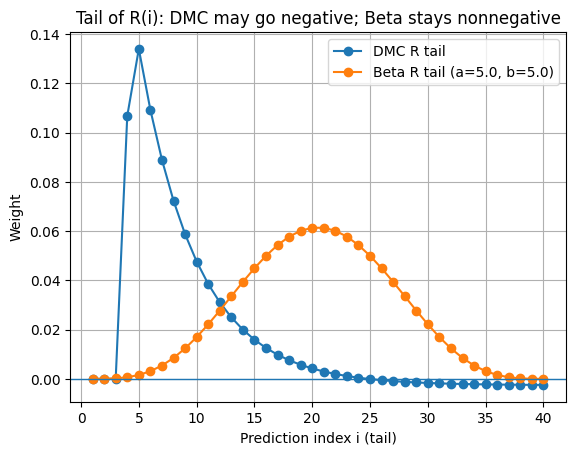

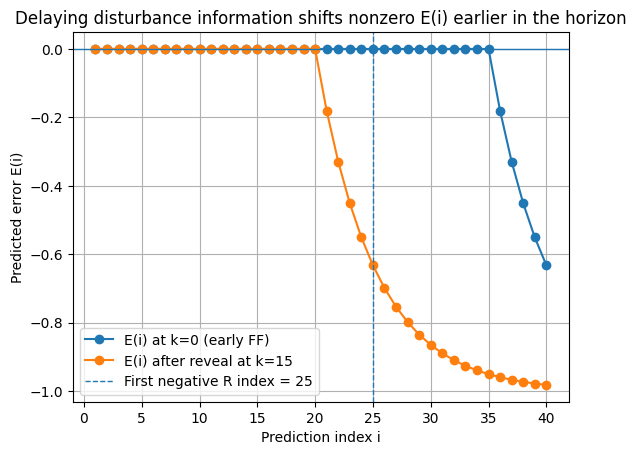

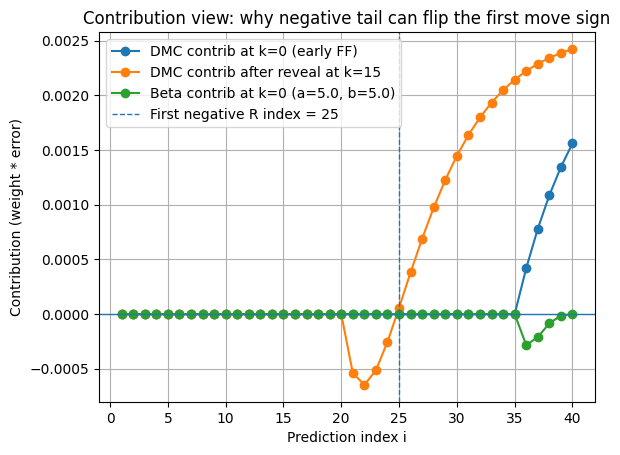

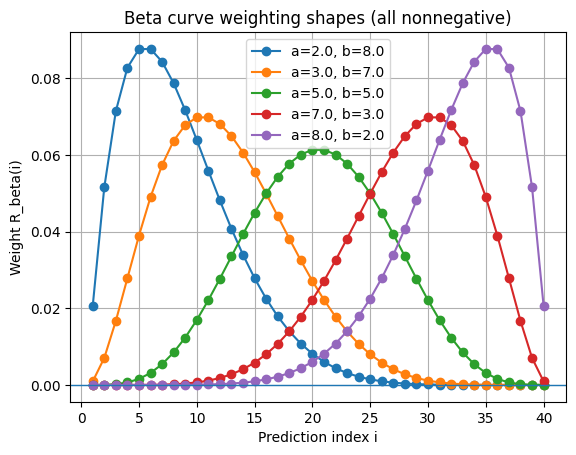

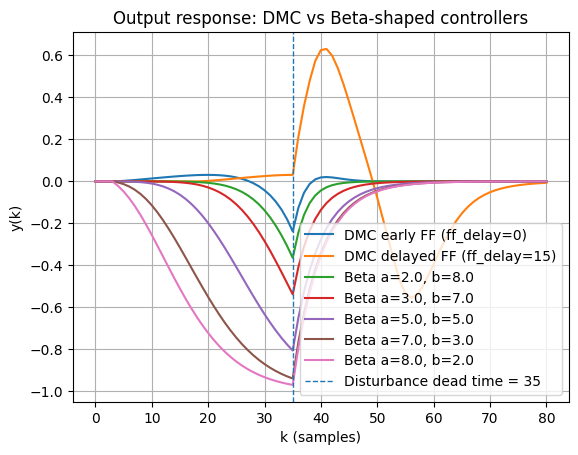

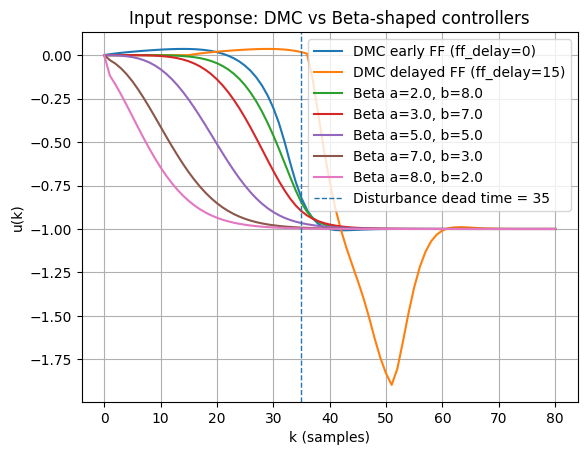

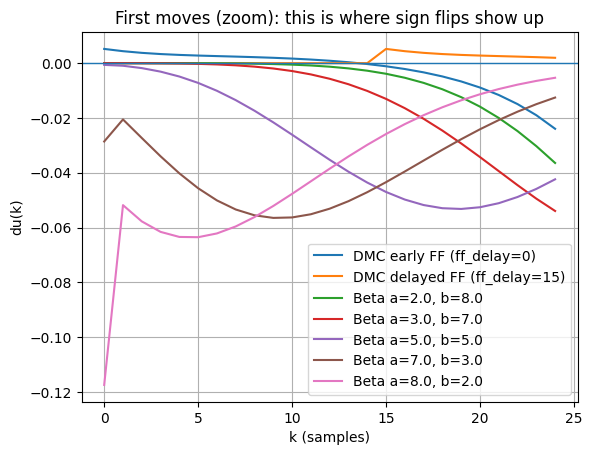

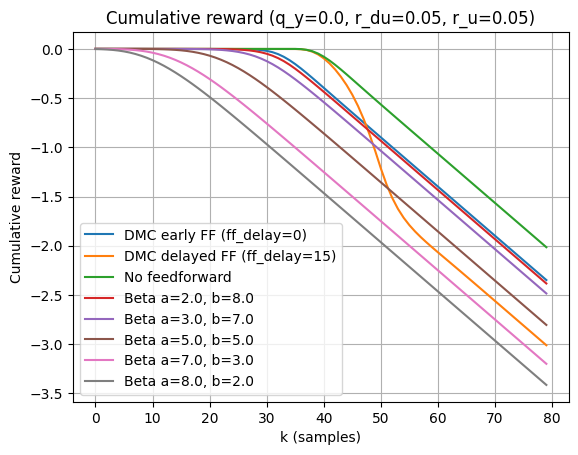

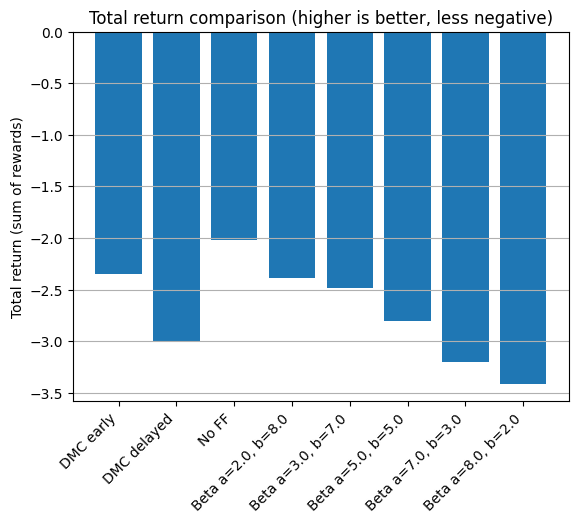

First move du_ff0[0] = 0.005194
First move du_ff5[0] = 0.000000
First move Beta a=2.0, b=8.0 du[0] = -0.000000
First move Beta a=3.0, b=7.0 du[0] = -0.000004
First move Beta a=5.0, b=5.0 du[0] = -0.000632
First move Beta a=7.0, b=3.0 du[0] = -0.028587
First move Beta a=8.0, b=2.0 du[0] = -0.117414


In [18]:
import numpy as np
import matplotlib.pyplot as plt


def fopdt_step_response(K, tau, dead_samples, n):
    """
    Discrete step response coefficients s[0..n], for a unit step occurring at time k.
    s[j] means: output change at (k + j) due to a unit step at time k.
    We set s[0] = 0.
    """
    s = np.zeros(n + 1, dtype=float)
    for j in range(1, n + 1):
        if j <= dead_samples:
            s[j] = 0.0
        else:
            s[j] = K * (1.0 - np.exp(-(j - dead_samples) / tau))
    return s


def build_dynamic_matrix(step, Np, Nu):
    """
    G[j-1, i-1] = step[j - i + 1] for j >= i else 0
    where step is the step response to a unit increment.
    """
    G = np.zeros((Np, Nu), dtype=float)
    for j in range(1, Np + 1):
        for i in range(1, Nu + 1):
            idx = j - i + 1
            if idx >= 1:
                G[j - 1, i - 1] = step[idx]
    return G


def dmc_first_move_gain(G, lam):
    """
    Kmat = (G^T G + lam I)^(-1) G^T
    R = first row of Kmat (maps error vector E to first move delta_u)
    """
    Nu = G.shape[1]
    Kmat = np.linalg.inv(G.T @ G + lam * np.eye(Nu)) @ G.T
    R = Kmat[0, :].copy()
    return Kmat, R


def predict_free_response(yk, du_hist, step_u, dd_hist, step_d, dd_current_ff, Np):
    """
    DMC "free response" prediction y0 over horizon, using:
    y0(j) = y(k) + sum_{i>=1} du(k-i) [s_u(i+j) - s_u(i)]
                 + sum_{i>=1} dd(k-i) [s_d(i+j) - s_d(i)]
                 + dd(k) * s_d(j)   (feedforward using the current measured disturbance increment)

    du_hist[0] is du(k-1), du_hist[1] is du(k-2), etc.
    same for dd_hist.
    """
    y0 = np.ones(Np, dtype=float) * yk

    nu_hist = len(du_hist)
    nd_hist = len(dd_hist)

    for j in range(1, Np + 1):
        acc = 0.0

        for i in range(1, nu_hist + 1):
            acc += du_hist[i - 1] * (step_u[i + j] - step_u[i])

        for i in range(1, nd_hist + 1):
            acc += dd_hist[i - 1] * (step_d[i + j] - step_d[i])

        acc += dd_current_ff * step_d[j]
        y0[j - 1] += acc

    return y0

import numpy as np

import matplotlib.pyplot as plt
plt.style.use('default')
from math import lgamma, log, exp


def beta_r_weights(Np, a, b):
    """
    Discrete Beta(a,b) shape over i=1..Np, normalized to sum to 1.
    Uses midpoint grid to avoid x=0 or x=1 singularities.
    """
    x = (np.arange(Np, dtype=float) + 0.5) / Np  # (0,1)
    log_B = lgamma(a) + lgamma(b) - lgamma(a + b)
    log_pdf = (a - 1.0) * np.log(x) + (b - 1.0) * np.log(1.0 - x) - log_B
    w = np.exp(log_pdf)
    w = w / (np.sum(w) + 1e-12)
    return w


def beta_gain_alpha(R_beta, step_u, Np, alpha_mode="weighted_gain", alpha_value=1.0):
    """
    Choose a scalar alpha so beta-shaped weights produce reasonable move sizes.

    alpha_mode:
      - "weighted_gain": alpha = 1 / (sum_i R_beta(i) * g(i)), where g(i) is the step response
                         This makes the weighted predicted change from du roughly match the weighted error.
      - "fixed": alpha = alpha_value
    """
    if alpha_mode == "fixed":
        return float(alpha_value)

    g = step_u[1:Np + 1]  # g(1..Np)
    denom = float(np.dot(R_beta, g))
    return 1.0 / (denom + 1e-9)



def simulate_dmc_case(
    step_u,
    step_d,
    Np,
    Nu,
    lam,
    n_sim,
    disturbance_step_time,
    use_early_feedforward=True,
    ff_delay=0,
    controller="dmc",
    R_beta=None,
    alpha_beta=1.0,
):
    G = build_dynamic_matrix(step_u, Np, Nu)
    Kmat, R_dmc = dmc_first_move_gain(G, lam)

    y = 0.0
    u = 0.0

    du_hist_plant = []
    dd_hist_plant = []

    du_hist_pred = []
    dd_hist_pred = []

    dd_meas_buffer = []

    y_log = [y]
    u_log = [u]
    du_log = []

    for k in range(n_sim):
        dd_true = 1.0 if k == disturbance_step_time else 0.0

        dd_meas_buffer.insert(0, dd_true)
        if use_early_feedforward:
            if len(dd_meas_buffer) > ff_delay:
                dd_ff = dd_meas_buffer[ff_delay]
            else:
                dd_ff = 0.0
        else:
            dd_ff = 0.0

        y0 = predict_free_response(
            yk=y,
            du_hist=du_hist_pred,
            step_u=step_u,
            dd_hist=dd_hist_pred,
            step_d=step_d,
            dd_current_ff=dd_ff,
            Np=Np,
        )

        yref = np.zeros(Np, dtype=float)
        E = yref - y0

        if controller == "dmc":
            deltaU = Kmat @ E
            du = float(deltaU[0])
        elif controller == "beta":
            if R_beta is None:
                raise ValueError("controller='beta' requires R_beta.")
            du = float(alpha_beta * np.dot(R_beta, E))
        else:
            raise ValueError("controller must be 'dmc' or 'beta'.")

        du_log.append(du)
        u += du

        du_hist_plant.insert(0, du)
        du_hist_pred.insert(0, du)

        dd_hist_plant.insert(0, dd_true)
        dd_hist_pred.insert(0, dd_ff)

        max_hist = 120
        du_hist_plant = du_hist_plant[:max_hist]
        du_hist_pred = du_hist_pred[:max_hist]
        dd_hist_plant = dd_hist_plant[:max_hist]
        dd_hist_pred = dd_hist_pred[:max_hist]
        dd_meas_buffer = dd_meas_buffer[:max_hist + ff_delay + 5]

        y_next = 0.0
        for i, v in enumerate(du_hist_plant, start=1):
            y_next += v * step_u[i]
        for i, v in enumerate(dd_hist_plant, start=1):
            y_next += v * step_d[i]

        y = y_next
        y_log.append(y)
        u_log.append(u)

    return np.array(y_log), np.array(u_log), np.array(du_log), R_dmc, G, Kmat

def compute_rewards(y, u, du, q_y=1.0, r_du=0.1, r_u=0.0):
    """
    Simple per-step reward aligned with du(k):
      r(k) = -(q_y * y(k+1)^2 + r_du * du(k)^2 + r_u * u(k+1)^2)
    y and u have length n_sim + 1, du has length n_sim.
    """
    y1 = y[1:]
    u1 = u[1:]
    r = -(q_y * (y1 ** 2) + r_du * (du ** 2) + r_u * (u1 ** 2))
    return r


def summarize_return(name, r):
    total = float(np.sum(r))
    avg = float(np.mean(r))
    print(f"{name}: total return = {total:.4f}, mean step reward = {avg:.4f}")
    return total


def run_beta_sweep(step_u, step_d, Np, Nu, lam, n_sim, disturbance_step_time, beta_pairs):
    """
    Runs multiple Beta controllers (early feedforward, ff_delay=0 by default)
    and returns a dict of results.
    """
    results = {}

    for a, b in beta_pairs:
        R_beta = beta_r_weights(Np, a, b)
        alpha_beta = beta_gain_alpha(R_beta, step_u, Np, alpha_mode="weighted_gain")

        y, u, du, _, _, _ = simulate_dmc_case(
            step_u, step_d, Np, Nu, lam, n_sim, disturbance_step_time,
            use_early_feedforward=True,
            ff_delay=0,
            controller="beta",
            R_beta=R_beta,
            alpha_beta=alpha_beta,
        )

        key = f"Beta a={a}, b={b}"
        results[key] = {
            "a": a,
            "b": b,
            "R_beta": R_beta,
            "alpha_beta": alpha_beta,
            "y": y,
            "u": u,
            "du": du,
        }

    return results

def compute_rewards_piecewise(
    y, u, du, dead_d,
    q_y=1.0, r_du=0.3, r_u=0.05,
    q_y_pre=0.05, r_du_pre=1.0, r_u_pre=0.2
):
    y1 = y[1:]
    u1 = u[1:]
    k = np.arange(len(du))

    q = np.where(k < dead_d, q_y_pre, q_y)
    rdu = np.where(k < dead_d, r_du_pre, r_du)
    ru = np.where(k < dead_d, r_u_pre, r_u)

    r = -(q * (y1 ** 2) + rdu * (du ** 2) + ru * (u1 ** 2))
    return r

def compute_rewards_with_wrongway(
    y, u, du, q_y=1.0, r_du=0.3, r_u=0.05, kappa=0.5
):
    y0 = y[:-1]
    y1 = y[1:]
    u1 = u[1:]

    wrongway = np.maximum(0.0, np.abs(y1) - np.abs(y0))
    r = -(q_y * (y1 ** 2) + r_du * (du ** 2) + r_u * (u1 ** 2) + kappa * wrongway)
    return r





def main():
    Ts = 1.0  # sample time (not explicitly used since we work in samples)

    # Plant used in the talk (slide 6):
    # G(s) = 1/(5s+1) * e^(-3s)
    K_u = 1.0
    tau_u = 5.0
    dead_u = 3  # samples

    # Disturbance: long transport delay (slide 15: "e.g., 35 samples")
    K_d = 1.0
    tau_d = 5.0
    dead_d = 35  # samples

    Np = 40  # inferred from slide 7 (inverse approx 0.032 when lambda=1)
    Nu = 3   # slide 12
    lam = 1.0

    n_model = 220  # must be > (max history + Np)
    step_u = fopdt_step_response(K_u, tau_u, dead_u, n_model)
    step_d = fopdt_step_response(K_d, tau_d, dead_d, n_model)

    n_sim = 80
    disturbance_step_time = 0

    a = 5.0
    b = 5.0
    R_beta = beta_r_weights(Np, a, b)
    alpha_beta = beta_gain_alpha(R_beta, step_u, Np, alpha_mode="weighted_gain")

    print(f"Beta params: a={a}, b={b}, alpha_beta={alpha_beta:.6f}")

    # Failure mode
    y_ff0, u_ff0, du_ff0, R, G, Kmat = simulate_dmc_case(
        step_u, step_d, Np, Nu, lam, n_sim, disturbance_step_time,
        use_early_feedforward=True,
        ff_delay=0,
    )


    # Fix by delaying feedforward info (try 5, 10, etc.)
    y_ff5, u_ff5, du_ff5, _, _, _ = simulate_dmc_case(
        step_u, step_d, Np, Nu, lam, n_sim, disturbance_step_time,
        use_early_feedforward=True,
        ff_delay=15,
    )

    # Baseline: no feedforward (controller ignores disturbance model)
    y_no, u_no, du_no, _, _, _ = simulate_dmc_case(
        step_u=step_u,
        step_d=step_d,
        Np=Np,
        Nu=Nu,
        lam=lam,
        n_sim=n_sim,
        disturbance_step_time=disturbance_step_time,
        use_early_feedforward=False,
    )

        # --- Beta sweep for presentation ---
    beta_pairs = [
        (2.0, 8.0),   # early-heavy
        (3.0, 7.0),   # early-heavy (less extreme)
        (5.0, 5.0),   # symmetric
        (7.0, 3.0),   # later-heavy
        (8.0, 2.0),   # later-heavy (more extreme)
    ]

    beta_results = run_beta_sweep(
        step_u=step_u,
        step_d=step_d,
        Np=Np,
        Nu=Nu,
        lam=lam,
        n_sim=n_sim,
        disturbance_step_time=disturbance_step_time,
        beta_pairs=beta_pairs,
    )

    # --- Piecewise reward settings (simple, matches the "too-early action" critique) ---
    q_y = 0.0
    r_du = 0.05
    r_u = 0.05

    q_y_pre = 0.0
    r_du_pre = 0.05
    r_u_pre = 0.05

    r_ff0 = compute_rewards_piecewise(
        y_ff0, u_ff0, du_ff0, dead_d,
        q_y=q_y, r_du=r_du, r_u=r_u,
        q_y_pre=q_y_pre, r_du_pre=r_du_pre, r_u_pre=r_u_pre
    )
    r_ff5 = compute_rewards_piecewise(
        y_ff5, u_ff5, du_ff5, dead_d,
        q_y=q_y, r_du=r_du, r_u=r_u,
        q_y_pre=q_y_pre, r_du_pre=r_du_pre, r_u_pre=r_u_pre
    )
    r_no = compute_rewards_piecewise(
        y_no, u_no, du_no, dead_d,
        q_y=q_y, r_du=r_du, r_u=r_u,
        q_y_pre=q_y_pre, r_du_pre=r_du_pre, r_u_pre=r_u_pre
    )



    total_ff0 = summarize_return("DMC early FF (ff_delay=0)", r_ff0)
    total_ff5 = summarize_return("DMC delayed FF (ff_delay=15)", r_ff5)
    total_no = summarize_return("No feedforward", r_no)

    beta_totals = {}
    for key, res in beta_results.items():
        r_beta = compute_rewards_piecewise(
            res["y"], res["u"], res["du"], dead_d,
            q_y=q_y, r_du=r_du, r_u=r_u,
            q_y_pre=q_y_pre, r_du_pre=r_du_pre, r_u_pre=r_u_pre
        )

        res["r"] = r_beta
        res["R_cum"] = np.cumsum(r_beta)
        beta_totals[key] = summarize_return(key, r_beta)

    # --- Presentation plot 1: Beta weight shapes (R_beta) ---
    k_idx = np.arange(1, Np + 1)

    # --- Extra presentation plots: show the negative tail + how delay changes where E lives ---
    neg = np.where(R < 0.0)[0]
    if len(neg) > 0:
        i_neg = int(neg[0]) + 1
    else:
        i_neg = None

    # "Early feedforward" at k=0: disturbance step just happened
    y0_early = step_d[1:Np + 1]
    E_early = -y0_early
    contrib_dmc_early = R * E_early

    # "Delayed information reveal" logic for visualization:
    # If you only learn about the disturbance after ff_delay samples,
    # then at that time the remaining delay is smaller, so the predicted response starts earlier.
    ff_delay_vis = 15
    y0_reveal = step_d[ff_delay_vis + 1:ff_delay_vis + Np + 1]
    E_reveal = -y0_reveal
    contrib_dmc_reveal = R * E_reveal

    contrib_beta_early = R_beta * E_early  # sign logic only; alpha just scales it

    du_dmc_early = float(np.sum(contrib_dmc_early))
    du_dmc_reveal = float(np.sum(contrib_dmc_reveal))
    du_beta_early = float(alpha_beta * np.dot(R_beta, E_early))

    print(f"DMC du from horizon sum (early FF, k=0) = {du_dmc_early:.6f}")
    print(f"DMC du from horizon sum (reveal after {ff_delay_vis}) = {du_dmc_reveal:.6f}")
    print(f"Beta du from horizon dot (early FF, k=0) = {du_beta_early:.6f}")

    # Plot: zoom on tail of R to show negative entries vs beta (nonnegative)
    tail = 0
    plt.figure()
    plt.plot(k_idx[-tail:], R[-tail:], marker="o", label="DMC R tail")
    plt.plot(k_idx[-tail:], R_beta[-tail:], marker="o", label=f"Beta R tail (a={a}, b={b})")
    plt.axhline(0.0, linewidth=1)
    plt.xlabel("Prediction index i (tail)")
    plt.ylabel("Weight")
    plt.title("Tail of R(i): DMC may go negative; Beta stays nonnegative")
    plt.grid(True)
    plt.legend()

    # Plot: where the predicted error sits (early vs revealed-late)
    plt.figure()
    plt.plot(k_idx, E_early, marker="o", label="E(i) at k=0 (early FF)")
    plt.plot(k_idx, E_reveal, marker="o", label=f"E(i) after reveal at k={ff_delay_vis}")
    if i_neg is not None:
        plt.axvline(i_neg, linestyle="--", linewidth=1, label=f"First negative R index = {i_neg}")
    plt.axhline(0.0, linewidth=1)
    plt.xlabel("Prediction index i")
    plt.ylabel("Predicted error E(i)")
    plt.title("Delaying disturbance information shifts nonzero E(i) earlier in the horizon")
    plt.grid(True)
    plt.legend()

    # Plot: contributions R(i)E(i) for DMC (early vs reveal) and Beta (early)
    plt.figure()
    plt.plot(k_idx, contrib_dmc_early, marker="o", label="DMC contrib at k=0 (early FF)")
    plt.plot(k_idx, contrib_dmc_reveal, marker="o", label=f"DMC contrib after reveal at k={ff_delay_vis}")
    plt.plot(k_idx, contrib_beta_early, marker="o", label=f"Beta contrib at k=0 (a={a}, b={b})")
    if i_neg is not None:
        plt.axvline(i_neg, linestyle="--", linewidth=1, label=f"First negative R index = {i_neg}")
    plt.axhline(0.0, linewidth=1)
    plt.xlabel("Prediction index i")
    plt.ylabel("Contribution (weight * error)")
    plt.title("Contribution view: why negative tail can flip the first move sign")
    plt.grid(True)
    plt.legend()


    plt.figure()
    for key, res in beta_results.items():
        plt.plot(k_idx, res["R_beta"], marker="o", label=f"a={res['a']}, b={res['b']}")
    plt.axhline(0.0, linewidth=1)
    plt.xlabel("Prediction index i")
    plt.ylabel("Weight R_beta(i)")
    plt.title("Beta curve weighting shapes (all nonnegative)")
    plt.grid(True)
    plt.legend()

    # --- Presentation plot 2: Output responses for Beta sweep + DMC ---
    t = np.arange(0, n_sim + 1)

    plt.figure()
    plt.plot(t, y_ff0, label="DMC early FF (ff_delay=0)")
    plt.plot(t, y_ff5, label="DMC delayed FF (ff_delay=15)")
    for key, res in beta_results.items():
        plt.plot(t, res["y"], label=key)
    plt.axvline(dead_d, linestyle="--", linewidth=1, label=f"Disturbance dead time = {dead_d}")
    plt.xlabel("k (samples)")
    plt.ylabel("y(k)")
    plt.title("Output response: DMC vs Beta-shaped controllers")
    plt.grid(True)
    plt.legend()

    # --- Presentation plot 3: Input u(k) responses (optional but good for intuition) ---
    plt.figure()
    plt.plot(t, u_ff0, label="DMC early FF (ff_delay=0)")
    plt.plot(t, u_ff5, label="DMC delayed FF (ff_delay=15)")
    for key, res in beta_results.items():
        plt.plot(t, res["u"], label=key)
    plt.axvline(dead_d, linestyle="--", linewidth=1, label=f"Disturbance dead time = {dead_d}")
    plt.xlabel("k (samples)")
    plt.ylabel("u(k)")
    plt.title("Input response: DMC vs Beta-shaped controllers")
    plt.grid(True)
    plt.legend()

    # --- Presentation plot 4: Zoom on early moves du(k) to show wrong-way behavior ---
    k = np.arange(0, n_sim)
    k_zoom = 25  # show first 25 samples

    plt.figure()
    plt.plot(k[:k_zoom], du_ff0[:k_zoom], label="DMC early FF (ff_delay=0)")
    plt.plot(k[:k_zoom], du_ff5[:k_zoom], label="DMC delayed FF (ff_delay=15)")
    for key, res in beta_results.items():
        plt.plot(k[:k_zoom], res["du"][:k_zoom], label=key)
    plt.axhline(0.0, linewidth=1)
    plt.xlabel("k (samples)")
    plt.ylabel("du(k)")
    plt.title("First moves (zoom): this is where sign flips show up")
    plt.grid(True)
    plt.legend()

    # --- Presentation plot 5: Cumulative reward curves ---
    plt.figure()
    plt.plot(k, np.cumsum(r_ff0), label="DMC early FF (ff_delay=0)")
    plt.plot(k, np.cumsum(r_ff5), label="DMC delayed FF (ff_delay=15)")
    plt.plot(k, np.cumsum(r_no), label="No feedforward")
    for key, res in beta_results.items():
        plt.plot(k, res["R_cum"], label=key)
    plt.xlabel("k (samples)")
    plt.ylabel("Cumulative reward")
    plt.title(f"Cumulative reward (q_y={q_y}, r_du={r_du}, r_u={r_u})")
    plt.grid(True)
    plt.legend()

    # --- Presentation plot 6: Total return bar chart (simple ranking) ---
    names = ["DMC early", "DMC delayed", "No FF"] + list(beta_totals.keys())
    totals = [total_ff0, total_ff5, total_no] + [beta_totals[n] for n in beta_totals]

    plt.figure()
    plt.bar(range(len(names)), totals)
    plt.xticks(range(len(names)), names, rotation=45, ha="right")
    plt.ylabel("Total return (sum of rewards)")
    plt.title("Total return comparison (higher is better, less negative)")
    plt.grid(True, axis="y")

    plt.show()

    print(f"First move du_ff0[0] = {du_ff0[0]:.6f}")
    print(f"First move du_ff5[0] = {du_ff5[0]:.6f}")
    for key, res in beta_results.items():
        print(f"First move {key} du[0] = {res['du'][0]:.6f}")


if __name__ == "__main__":
    main()
